# 07. Self-Organizing Maps (SOM): Kohonen Network with MiniSom
**Algorithm Covered:**
- **Self-Organizing Map (Kohonen Neural Network)**

**Core Concepts:**
- Unsupervised topological dimensionality reduction
- Competitive learning and Best Matching Unit (BMU) search
- Gaussian neighborhood decay and weight adaptation
- Unified Distance Matrix (**U-Matrix**) & Win Map visualization
- Model quality metrics: **Quantization Error** and **Topographic Error**

**Dataset:** UCI Wine Recognition Dataset (178 samples, 13 continuous chemical constituents, 3 wine cultivars)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("MiniSom and libraries loaded successfully!")


MiniSom and libraries loaded successfully!


## 1. Dataset Loading and Feature Scaling
The Wine dataset features 13 chemical constituents (alcohol, malic acid, ash, flavanoids, color intensity, etc.) across 3 distinct wine cultivars.


In [2]:
wine = load_wine()
X_raw = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Samples: {X_raw.shape[0]}, Features: {X_raw.shape[1]}, Classes: {target_names.tolist()}")

# MinMax scaling to [0, 1] range (recommended for SOM weight stability)
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)


Samples: 178, Features: 13, Classes: ['class_0', 'class_1', 'class_2']


## 2. Mathematical Principles of the Kohonen SOM
A Self-Organizing Map arranges $M \times N$ neurons on a regular 2D grid. Each neuron $j$ has a weight vector $w_j \in \mathbb{R}^d$.

### Competitive Phase:
For input vector $x$, the **Best Matching Unit (BMU)** $c$ is determined by Euclidean distance:
$$c = \arg\min_j \|x - w_j\|$$

### Cooperative & Adaptive Phase:
Neurons in the topological neighborhood of $c$ are pulled toward $x$:
$$w_j(t+1) = w_j(t) + \alpha(t) h_{cj}(t) [x - w_j(t)]$$
where:
- $\alpha(t) = \alpha_0 \exp(-t / \tau_1)$ is the decaying learning rate.
- $h_{cj}(t) = \exp\left(-\frac{\|r_c - r_j\|^2}{2\sigma(t)^2}\right)$ is the Gaussian neighborhood kernel on grid coordinates $r$.
- $\sigma(t) = \sigma_0 \exp(-t / \tau_2)$ is the decaying neighborhood spread.


In [3]:
# Setting up Kohonen Grid
grid_x, grid_y = 12, 12  # 12x12 grid (144 neurons for 178 samples)
input_len = X.shape[1]    # 13 features

som = MiniSom(
    x=grid_x,
    y=grid_y,
    input_len=input_len,
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)

# PCA weight initialization for faster, topologically faithful convergence
som.pca_weights_init(X)
print("Initial Quantization Error:", som.quantization_error(X))

# Train SOM
som.train_random(data=X, num_iteration=5000, verbose=False)
final_qe = som.quantization_error(X)
final_te = som.topographic_error(X)

print(f"Training complete after 5,000 iterations!")
print(f" - Final Quantization Error (mean distance to BMU): {final_qe:.4f}")
print(f" - Final Topographic Error (proportion of foldings): {final_te:.4f}")


Initial Quantization Error: 0.4447391189659704


Training complete after 5,000 iterations!
 - Final Quantization Error (mean distance to BMU): 0.1965
 - Final Topographic Error (proportion of foldings): 0.0393


## 3. Visualizing the Unified Distance Matrix (U-Matrix)
The **U-Matrix** computes the average Euclidean distance between each neuron and its immediate grid neighbors.
- **Dark/Blue valleys:** High data density (clusters of similar samples).
- **Bright/Yellow ridges:** Topological boundaries and low-density barriers separating clusters.


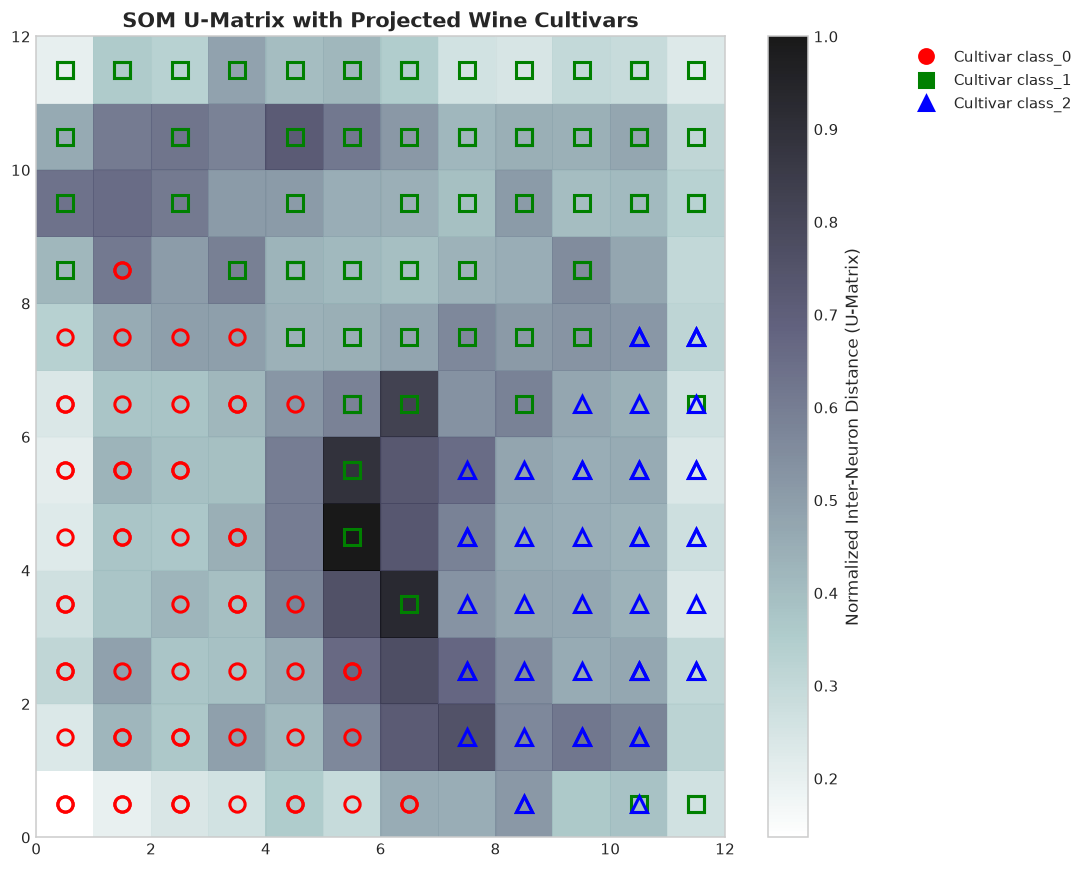

In [4]:
# Plotting U-Matrix
plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.9)
cbar = plt.colorbar()
cbar.set_label("Normalized Inter-Neuron Distance (U-Matrix)", fontsize=11)

# Markers and colors for each wine cultivar
markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']

for idx, x_vec in enumerate(X):
    w = som.winner(x_vec) # Coordinates of the BMU
    plt.plot(
        w[0] + 0.5,
        w[1] + 0.5,
        markers[y[idx]],
        markerfacecolor='None',
        markeredgecolor=colors[y[idx]],
        markersize=10,
        markeredgewidth=2
    )

# Legend
for c_idx, c_name in enumerate(target_names):
    plt.plot([], [], marker=markers[c_idx], color=colors[c_idx], linestyle='None',
             label=f'Cultivar {c_name}', markersize=9, markeredgewidth=2)

plt.title("SOM U-Matrix with Projected Wine Cultivars", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Win Map & Component Planes
1. **Win Map:** Tracks the frequency with which each grid neuron acts as BMU for samples.
2. **Component Planes:** Visualizes the weight values of individual features across the 2D grid, revealing correlations.


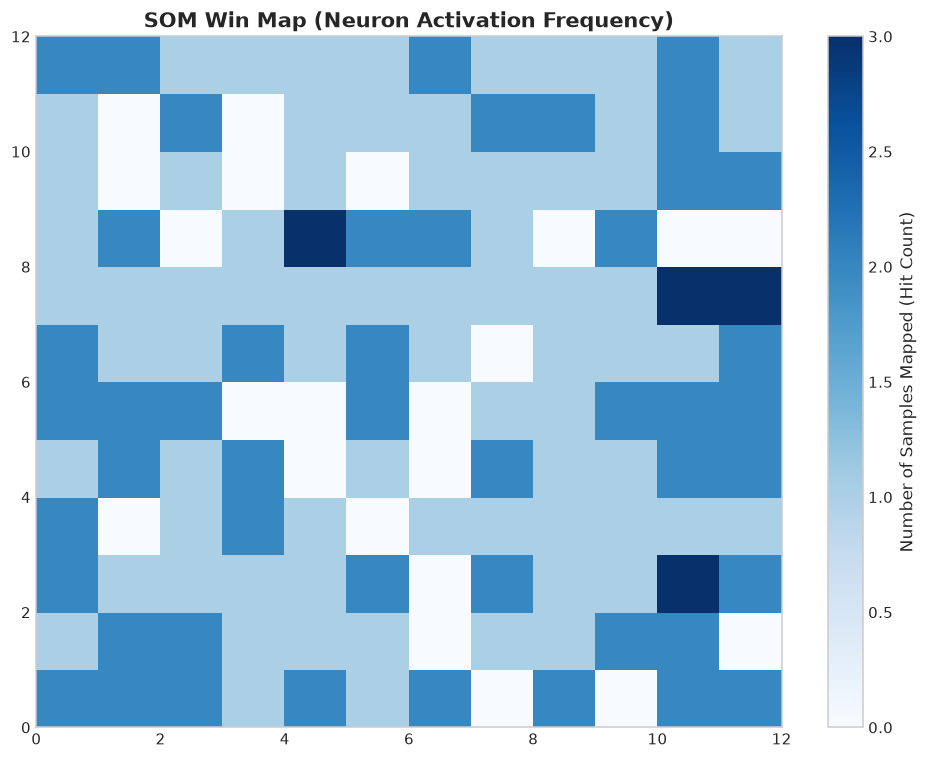

In [5]:
# Win Map (Hit Histogram)
frequencies = som.activation_response(X)

plt.figure(figsize=(9, 7))
plt.pcolor(frequencies.T, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label("Number of Samples Mapped (Hit Count)", fontsize=11)
plt.title("SOM Win Map (Neuron Activation Frequency)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


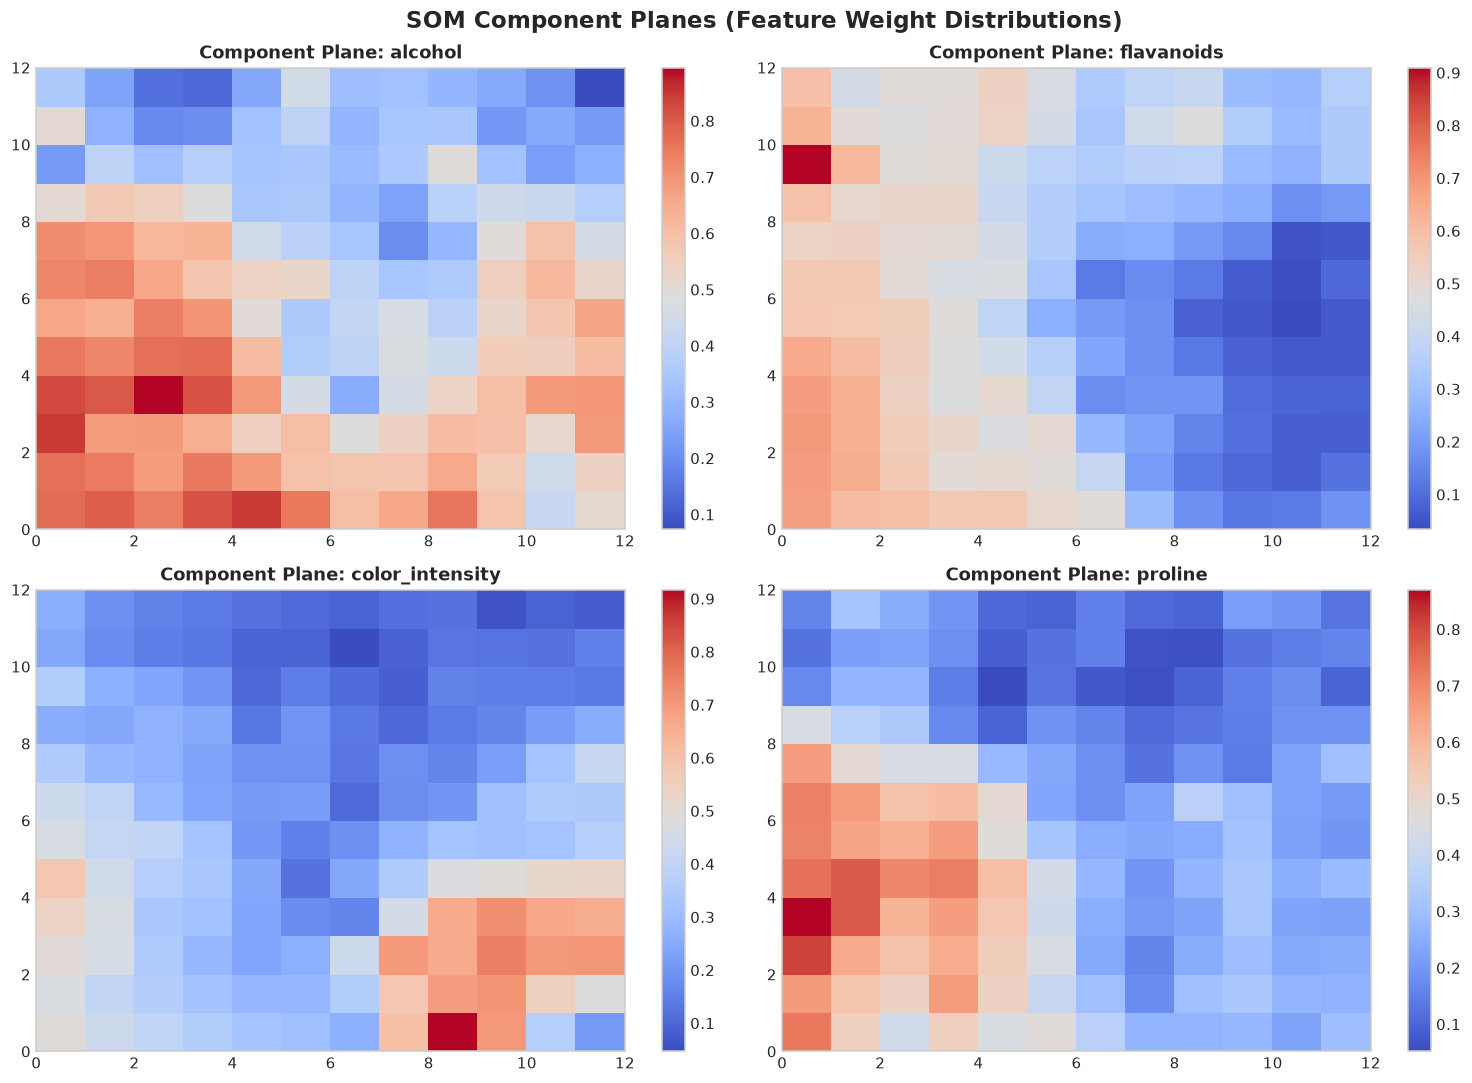

In [6]:
# Component Planes for Key Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
selected_features = [0, 6, 9, 12] # Alcohol, Flavanoids, Color intensity, Proline

for ax, feat_idx in zip(axes.flat, selected_features):
    weights = som.get_weights()[:, :, feat_idx]
    im = ax.pcolor(weights.T, cmap='coolwarm')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Component Plane: {feature_names[feat_idx]}", fontsize=12, fontweight='bold')

plt.suptitle("SOM Component Planes (Feature Weight Distributions)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Summary & Key Properties of SOM
1. **Topological Preservation:** High-dimensional neighbor relations are faithfully mapped into adjacent neurons on the 2D grid.
2. **Unsupervised Class Discovery:** Without accessing target labels $y$ during training, the SOM naturally segregates the three wine cultivars into distinct geographic regions on the U-matrix.
3. **Interpretability:** Component planes provide direct visual correlation analysis between input variables across the manifold.
